## Name : `Sai sourav Panigrahi`
### Batch No. : 501

# AI-Powered Resume Screening and ATS Matching System

## Problem Statement
Recruiters often receive hundreds of resumes for a single job opening, making the screening process time-consuming and inefficient. Manually reviewing resumes to identify suitable candidates based on skills and job requirements can lead to delays and increased effort in the recruitment process. Therefore, there is a need for an automated system that can assist recruiters in efficiently evaluating and shortlisting candidates.

## Objectives

- Automatically classify resumes into job categories.
- Preprocess resume text for machine learning.
- Convert text into numerical features using TF-IDF.
- Compare multiple machine learning models.
- Select the best model using hyperparameter tuning.
- Build the foundation for ATS-based resume matching.

## Importing Required libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [2]:
df = pd.read_csv("dataset/Resume/Resume.csv")

In [3]:

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Dataset Summary

- **Source:** Kaggle Resume Dataset
- **Total Records:** 2484
- **Text Feature:** Resume_str
- **Target Variable:** Category
- **Problem Type:** Multi-Class Text Classification

## Data Understanding

In [141]:
df.shape

(2484, 4)

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 52.3 MB


In [143]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [144]:
df.sample(10)

,ID,Resume_str,Resume_html,Category
742,32219038,ENUMERATOR Summary Recent gr...,"<div class=""fontsize fontface vmargins hmargin...",HEALTHCARE
1710,24647794,ENGINEERING INTERN Profile ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING
2117,11635137,MARKETING & COMMUNICATIONS EXECUTIVE ...,"<div class=""fontsize fontface vmargins hmargin...",PUBLIC-RELATIONS
119,13774329,MECHANICAL DESIGNER Summary ...,"<div class=""fontsize fontface vmargins hmargin...",DESIGNER
107,32308556,HR VOLUNTEER ASST. MANAGER Prof...,"<div class=""fontsize fontface vmargins hmargin...",HR
228,14789139,DIRECTOR OF INFORMATION TECHNOLOGY ...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY
1046,51349448,SALES COORDINATOR Summary L...,"<div class=""fontsize fontface vmargins hmargin...",SALES
1635,12860543,FREELANCE DESIGNER Highlights...,"<div class=""fontsize fontface vmargins hmargin...",APPAREL
2216,13173522,VICE PRESIDENT OF MEMBERSHIP ...,"<div class=""fontsize fontface vmargins hmargin...",BANKING
1444,30337969,"OWNER, PERSONAL CHEF Area...","<div class=""fontsize fontface vmargins hmargin...",CHEF


### Observation

- The dataset contains one numerical column (ID) and three text columns.
- Resume_str contains the resume text.
- Resume_html contains the HTML version of resumes.
- Category is the target variable used for classification.

## Missing Values 

In [145]:
df.isna().sum().sum()

np.int64(0)

### Observation
- There is no missing  values present in the dataset

## Duplicate Records

In [146]:
df.duplicated().sum()

np.int64(0)

### observation
- There is no duplicate value present in the Dataset

## Exploratory Data Analysis

### Category distribution

In [147]:
df["Category"].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

C:\Users\panig\AppData\Local\Temp\ipykernel_5624\605570246.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


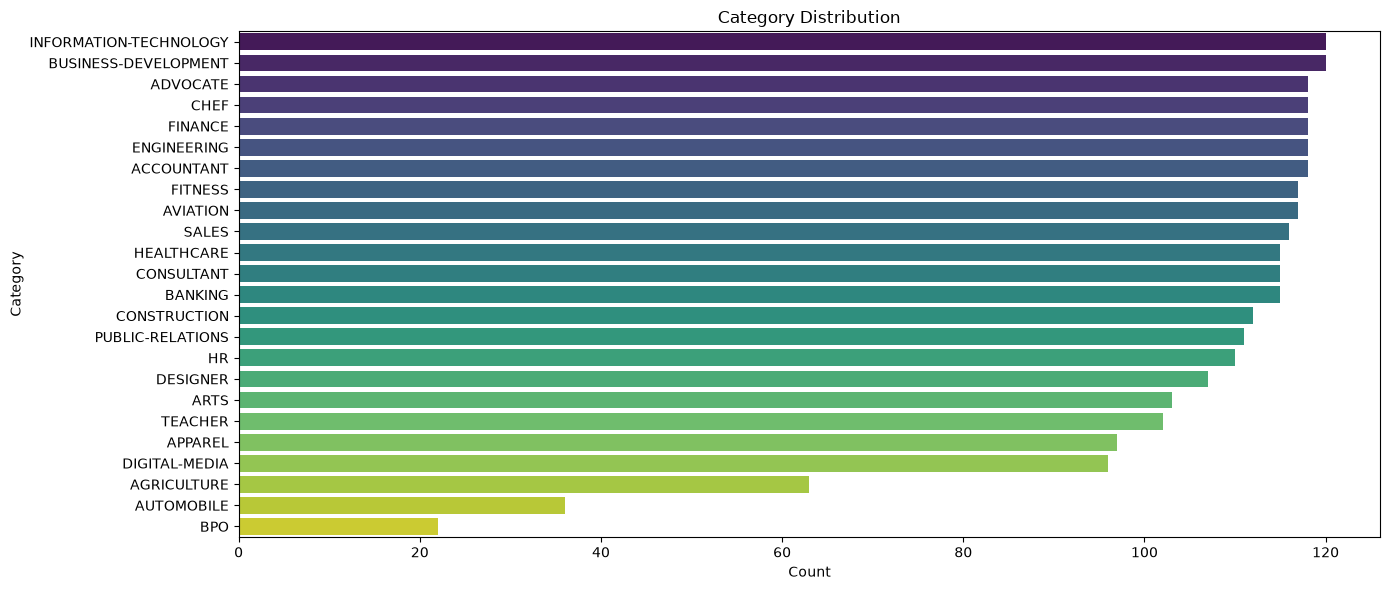

In [148]:
plt.figure(figsize=(14,6))

sns.countplot(
    y=df["Category"],
    order=df["Category"].value_counts().index,
    palette="viridis"
)

plt.title("Category Distribution")
plt.ylabel("Category")
plt.xlabel("Count")



plt.tight_layout()

plt.show()

### Observation

- The dataset contains resumes from multiple job categories.
- Most categories have a similar number of resumes, indicating a fairly balanced dataset.
- Categories such as Information Technology and Business Development have the highest number of resumes.
- Categories such as BPO and Automobile contain comparatively fewer resumes.
- Overall, the dataset is suitable for building a multi-class classification model.

### Resume Length

In [149]:
df["Resume_Length"] = df["Resume_str"].apply(len)

In [150]:
df["Resume_Length"].describe()

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: Resume_Length, dtype: float64

### Observation

- The average resume length is approximately 6,295 characters.
- Most resumes contain between 5,160 and 7,227 characters.
- Some resumes are significantly longer than average.

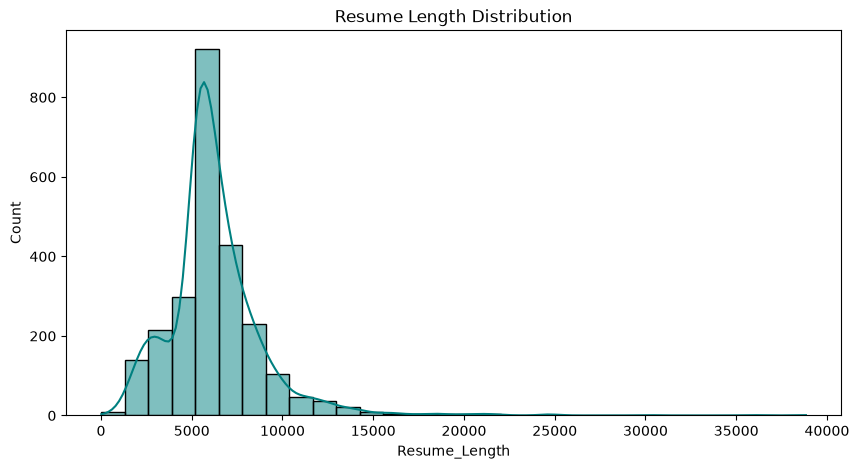

In [151]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Resume_Length"],
    bins=30,
    kde=True,
    color="teal"
)

plt.title("Resume Length Distribution")
plt.show()

### Observation

- Most resumes are concentrated around the average length.
- The distribution is right-skewed, indicating the presence of some very long resumes.
- A few resumes can be considered potential outliers in terms of length.

## Character Count

In [178]:
df["Character_Count"] = df["Resume_str"].str.len()

df["Character_Count"].describe()

count     2484.000000
mean      6295.308776
std       2769.251458
min         21.000000
25%       5160.000000
50%       5886.500000
75%       7227.250000
max      38842.000000
Name: Character_Count, dtype: float64

### Observation

- Character count varies across resumes.
- Longer resumes generally contain more detailed information.

## Word Count

In [180]:
df["Word_Count"] = df["Resume_str"].apply(lambda x: len(str(x).split()))

df["Word_Count"].describe()

count    2484.000000
mean      811.325684
std       371.006906
min         0.000000
25%       651.000000
50%       757.000000
75%       933.000000
max      5190.000000
Name: Word_Count, dtype: float64

## Sentence Count

In [181]:
df["Sentence_Count"] = df["Resume_str"].apply(
    lambda x: len(re.findall(r"[.!?]", str(x)))
)

df["Sentence_Count"].describe()

count    2484.000000
mean       39.715378
std        28.845051
min         0.000000
25%        22.750000
50%        37.000000
75%        50.000000
max       634.000000
Name: Sentence_Count, dtype: float64

## Average Word Length

In [183]:
df["Average_Word_Length"] = df["Resume_str"].apply(
    lambda x: sum(len(word) for word in str(x).split()) / max(len(str(x).split()),1)
)

df["Average_Word_Length"].describe()

count    2484.000000
mean        6.303609
std         0.391513
min         0.000000
25%         6.106893
50%         6.332170
75%         6.549277
max         7.551282
Name: Average_Word_Length, dtype: float64

# Feature Engineering

In [184]:
# Stopword Count
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["Stopword_Count"] = df["Resume_str"].apply(
    lambda x: sum(
        word.lower() in stop_words
        for word in str(x).split()
    )
)

In [185]:
# Digit Count
df["Digit_Count"] = df["Resume_str"].str.count(r"\d")

In [186]:
# Capital Count
df["Capital_Count"] = df["Resume_str"].apply(
    lambda x: sum(1 for c in str(x) if c.isupper())
)

In [188]:
# Punctuation Count
import string

df["Punctuation_Count"] = df["Resume_str"].apply(
    lambda x: sum(1 for c in str(x) if c in string.punctuation)
)

## Text Preprocessing

In [152]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [153]:
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\panig\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\panig\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [154]:
# Create preprocessing Function
def preprocess_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    stop_words = set(stopwords.words("english"))

    words = [
        word
        for word in text.split()
        if word not in stop_words
    ]

    lemmatizer = WordNetLemmatizer()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)

In [155]:
# Applying on Resume Column
df["Clean_Resume"] = df["Resume_str"].apply(preprocess_text)

In [156]:
# Comparision on Before and after
print("Original Resume:\n")
print(df["Resume_str"][0][:1000])

print("\n\n")

print("Clean Resume:\n")
print(df["Clean_Resume"][0][:1000])

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory c

### Observation

- Text preprocessing successfully converted resume text into a clean and standardized format.
- Punctuation, special characters, and stopwords were removed from the text.
- The cleaned text is more suitable for feature extraction and machine learning model training.

## Word cloud

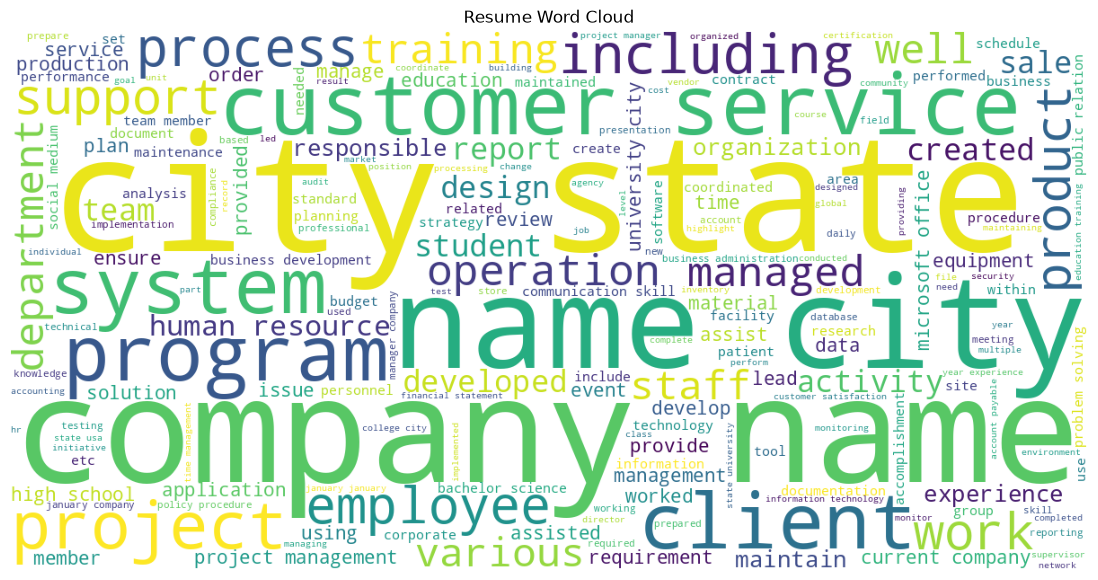

In [157]:
from wordcloud import WordCloud
text = " ".join(df["Clean_Resume"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Resume Word Cloud")
plt.show()

### Observation
- Word Cloud provides a quick overview of the most frequently occurring words before feature extraction.

## TF-IDF Feature Extraction

In [158]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X = vectorizer.fit_transform(df["Clean_Resume"])
y = df["Category"]

In [159]:
print(X.shape)
print(y.shape)

(2484, 10000)
(2484,)


### Observation

- TF-IDF successfully converted the resume text into numerical feature vectors.
- The transformed dataset contains 2484 resumes and 5000 text features.
- These features will be used for training machine learning classification models.

# Train Test Split

In [160]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [161]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1987, 10000)
X_test : (497, 10000)
y_train: (1987,)
y_test : (497,)


### Observation

- The dataset was divided into training and testing sets.
- 80% of the data was used for training and 20% for testing.
- Stratified sampling preserved the category distribution in both datasets.

# Model Building


In [162]:
# Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.5472837022132797


### Observation

- Multinomial Naive Bayes was trained on the TF-IDF features.
- The model provides a baseline performance for resume classification.

In [163]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.6539235412474849


### Observation

- Logistic Regression was trained on the TF-IDF features.
- The model captures linear relationships between text features and job categories.

In [164]:
# Linear SVM
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Accuracy: 0.7263581488933601


### Observation

- Linear SVM was trained on the TF-IDF features.
- SVM is generally effective for high-dimensional text classification tasks.

In [165]:
# Accuracy comparision Table
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Linear SVM,0.726358
1,Logistic Regression,0.653924
0,Naive Bayes,0.547284


### Observation

- Linear SVM achieved the highest accuracy among all models.
- Logistic Regression performed moderately well.
- Naive Bayes showed the lowest accuracy.
- Therefore, Linear SVM was selected as the final model.

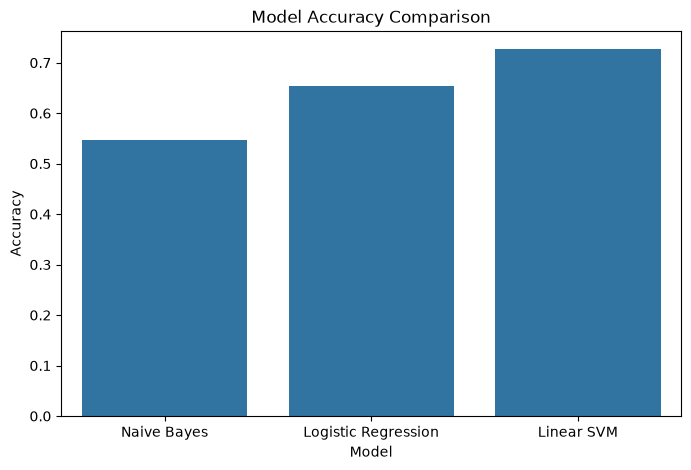

In [166]:
# Accuracy Comparison Graph
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.show()

### Observation

- Linear SVM outperformed the other classification models.
- The comparison confirms that SVM is the most suitable model for this dataset.

1. Naive Bayes Tuning

In [167]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)

print("Best Parameters:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

Best Parameters: {'alpha': 0.1}
Best CV Score: 0.5561079958988899


In [168]:
# 2. Logistic Regression Tuning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

Best Parameters: {'C': 100}
Best CV Score: 0.6799159525587636


In [169]:
# 3. Linear SVM Tuning
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_svm = GridSearchCV(
    LinearSVC(
    C=10,max_iter=20000,dual=False),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

Best Parameters: {'C': 1}
Best CV Score: 0.7040833892383834


In [170]:
print("Naive Bayes :", grid_nb.best_score_)
print("Logistic Regression :", grid_lr.best_score_)
print("Linear SVM :", grid_svm.best_score_)

Naive Bayes : 0.5561079958988899
Logistic Regression : 0.6799159525587636
Linear SVM : 0.7040833892383834


In [171]:
from sklearn.metrics import accuracy_score

best_svm = grid_svm.best_estimator_

y_pred = best_svm.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7263581488933601


In [172]:
from sklearn.metrics import accuracy_score
import pandas as pd

# Test Accuracy
nb_acc = accuracy_score(y_test, grid_nb.best_estimator_.predict(X_test))
lr_acc = accuracy_score(y_test, grid_lr.best_estimator_.predict(X_test))
svm_acc = accuracy_score(y_test, grid_svm.best_estimator_.predict(X_test))

# Comparison Table
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Best Parameters": [
        str(grid_nb.best_params_),
        str(grid_lr.best_params_),
        str(grid_svm.best_params_)
    ],
    "Cross Validation Accuracy": [
        round(grid_nb.best_score_, 4),
        round(grid_lr.best_score_, 4),
        round(grid_svm.best_score_, 4)
    ],
    "Test Accuracy": [
        round(nb_acc, 4),
        round(lr_acc, 4),
        round(svm_acc, 4)
    ]
})

comparison = comparison.sort_values(by="Test Accuracy", ascending=False)

comparison

,Model,Best Parameters,Cross Validation Accuracy,Test Accuracy
2,Linear SVM,{'C': 1},0.7041,0.7264
1,Logistic Regression,{'C': 100},0.6799,0.7062
0,Naive Bayes,{'alpha': 0.1},0.5561,0.5795


C:\Users\panig\AppData\Local\Temp\ipykernel_5624\2321790986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


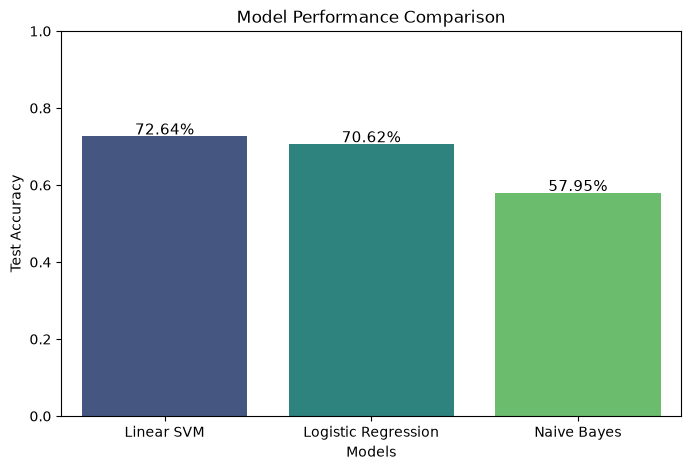

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Test Accuracy",
    palette="viridis"
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")

for i, v in enumerate(comparison["Test Accuracy"]):
    plt.text(i, v + 0.005, f"{v:.2%}", ha="center", fontsize=11)

plt.ylim(0, 1)
plt.show()

# Model Evaluation


### Classification Report (Final SVM)

In [174]:
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.75      0.88      0.81        24
              ADVOCATE       0.60      0.62      0.61        24
           AGRICULTURE       0.90      0.69      0.78        13
               APPAREL       0.64      0.37      0.47        19
                  ARTS       0.69      0.43      0.53        21
            AUTOMOBILE       1.00      0.29      0.44         7
              AVIATION       0.83      0.79      0.81        24
               BANKING       0.83      0.83      0.83        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.69      0.83      0.75        24
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.75      0.82      0.78        22
            CONSULTANT       0.82      0.39      0.53        23
              DESIGNER       0.86      0.90      0.88        21
         DIGITAL-MEDIA       0.75      

### Observation

- Linear SVM achieved balanced Precision, Recall, and F1-Score across most categories.
- The model demonstrated good generalization on unseen resumes.
- Overall performance indicates that the model is suitable for resume classification.

## Confusion Matrix

In [175]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)


In [189]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision :", precision_score(y_test, y_pred, average="weighted"))
print("Recall    :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score  :", f1_score(y_test, y_pred, average="weighted"))

Precision : 0.7348872598322823
Recall    : 0.7263581488933601
F1 Score  : 0.7169152650700069


In [176]:
import joblib

joblib.dump(best_svm, "resume_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [190]:
loaded_model = joblib.load("resume_classifier.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


# Conclusion

- Successfully developed a Resume Screening and ATS Matching System.
- Applied text preprocessing and TF-IDF feature extraction.
- Compared multiple machine learning models.
- Linear SVM achieved the best performance with **73.44%** accuracy after hyperparameter tuning.
- The trained model will be integrated into a Streamlit-based ATS application for resume screening and job description matching.

In [6]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64